# AirBnB Madrid

Uno de nuestros clientes opera en el mercado de inmuebles. Está especialmente
interesado en Madrid, donde posee una cantidad importante de viviendas
publicadas en la plataforma AirBnB y nos pide que le asesoremos respondiendo a
la siguiente pregunta:

<div style="text-align:center; color:red; font-size:larger; font-weight:bold; border: 2px solid red; padding: 10px;">
    ¿Qué puedo hacer para optimizar el precio de mis viviendas?
</div>

El objetivo del proyecto será elaborar un Data Storytelling que de respuesta a
nuestro cliente siguiendo los siguientes pasos:

1. Elaborar un contexto del problema
2. Definir el problema que queremos resolver
3. Definir y desarrollar el roadmap del análisis
4. Recopilar los principales insights para montar el data storytelling final:
    - contexto
    - problema
    - insights

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 0. Data

Para realizar este proyecto contamos con el siguiente set de datos:

| Fichero                          | Descripción                                                                 |
|----------------------------------|-----------------------------------------------------------------------------|
| airbnb_madrid_host.parquet       | Información del propietario de cada vivienda.                               |
| airbnb_madrid_location.parquet   | Información de la localización de cada vivienda.                            |
| airbnb_madrid_property.parquet   | Información de la vivienda.                                                 |
| airbnb_madrid_conditions.parquet | Información de las condiciones de cada vivienda para poder alquilarla.      |
| airbnb_madrid_reviews.parquet    | Información de las reseñas de cada vivienda.                                |

Y en cada set de datos se cuenta con las siguientes variables:

airbnb_madrid_host.parquet

| Columna                          | Descripción                                                                 |
|----------------------------------|-----------------------------------------------------------------------------|
| id                               | Identificador único de la publicación en Airbnb.                            |
| host_response_time               | Tiempo que tarda el anfitrión en responder a las consultas.                 |
| host_response_rate               | Tasa de respuesta del anfitrión.                                            |
| host_is_superhost                | Indica si el anfitrión es un "superhost" o no.                              |
| host_has_profile_pic             | Indica si el anfitrión tiene una foto de perfil en su cuenta.               |
| host_identity_verified           | Indica si la identidad del anfitrión ha sido verificada por Airbnb.         |
| host_seniority                   | Antigüedad del anfitrión como miembro de Airbnb.                            |
| host_verifications_email         | Indica si el anfitrión ha verificado su correo electrónico.                 |
| host_verifications_phone         | Indica si el anfitrión ha verificado su número de teléfono.                 |
| host_verifications_reviews       | Indica si el anfitrión ha verificado a través de reseñas de otros huéspedes.|
| host_verifications_facebook      | Indica si el anfitrión ha verificado su cuenta de Facebook.                 |
| calculated_host_listings_count   | Número de propiedades que el anfitrión tiene en Airbnb.                     |
| host_verifications_government_id | Indica si el anfitrión ha verificado su identificación gubernamental.       |

airbnb_madrid_location.parquet

| Columna                          | Descripción                                                                 |
|----------------------------------|-----------------------------------------------------------------------------|
| id                               | Identificador único de la publicación en Airbnb.                            |
| neighbourhood                    | Barrio donde se encuentra la propiedad.                                     |
| neighbourhood_group              | Grupo de barrios al que pertenece el barrio.                                |
| latitude                         | Latitud de la ubicación de la propiedad.                                    |
| longitude                        | Longitud de la ubicación de la propiedad.                                   |
| dist_km_sol                      | Distancia en kilómetros desde la propiedad hasta la plaza de de Sol.        |
| dist_km_airport                  | Distancia en kilómetros desde la propiedad hasta el aeropuerto.             |

airbnb_madrid_property.parquet

| Columna                          | Descripción                                                                 |
|----------------------------------|-----------------------------------------------------------------------------|
| id                               | Identificador único de la publicación en Airbnb.                            |
| property_type                    | Tipo de propiedad (casa, apartamento, etc.).                                |
| room_type                        | Tipo de habitación (compartida, privada, etc.).                             |
| accommodates                     | Número máximo de huéspedes que pueden alojarse en la propiedad.             |
| bathrooms                        | Número de baños en la propiedad.                                            |
| bedrooms                         | Número de dormitorios en la propiedad.                                      |
| beds                             | Número de camas en la propiedad.                                            |
| bed_type                         | Tipo de cama (individual, doble, etc.).                                     |
| amenities_wifi_internet          | Indica si la propiedad ofrece wifi o internet como amenidad.                |
| amenities_tv                     | Indica si la propiedad ofrece televisión como amenidad.                     |
| amenities_air_conditioning       | Indica si la propiedad ofrece aire acondicionado como amenidad.             |
| amenities_heating                | Indica si la propiedad ofrece calefacción como amenidad.                    |
| amenities_kitchen                | Indica si la propiedad ofrece cocina como amenidad.                         |

airbnb_madrid_conditions.parquet

| Columna                          | Descripción                                                                 |
|----------------------------------|-----------------------------------------------------------------------------|
| id                               | Identificador único de la publicación en Airbnb.                            |
| price                            | Precio de alquiler por noche de la propiedad.                               |
| minimum_nights                   | Mínimo de noches requeridas para reservar la propiedad.                     |
| maximum_nights                   | Máximo de noches permitidas para reservar la propiedad.                     |
| cancellation_policy              | Política de cancelación de reservas de la propiedad.                        |
| require_guest_profile_picture    | Indica si se requiere foto de perfil de los huéspedes.                      |
| require_guest_phone_verification | Indica si se requiere verificación telefónica de los huéspedes.             |

airbnb_madrid_reviews.parquet

| Columna                          | Descripción                                                                 |
|----------------------------------|-----------------------------------------------------------------------------|
| id                               | Identificador único de la publicación en Airbnb.                            |
| number_of_reviews                | Número total de reseñas recibidas para la propiedad.                        |
| number_of_reviews_ltm            | Número de reseñas recibidas en el último año.                               |
| review_scores_rating             | Puntuación general de reseñas de la propiedad.                              |
| review_scores_accuracy           | Puntuación de precisión en las reseñas de la propiedad.                     |
| review_scores_cleanliness        | Puntuación de limpieza en las reseñas de la propiedad.                      |
| review_scores_checkin            | Puntuación de check-in en las reseñas de la propiedad.                      |
| review_scores_communication      | Puntuación de comunicación en las reseñas de la propiedad.                  |
| review_scores_location           | Puntuación de ubicación en las reseñas de la propiedad.                     |
| review_scores_value              | Puntuación de valor en las reseñas de la propiedad.                         |
| reviews_per_month                | Número promedio de reseñas por mes para la propiedad.                       |
| days_since_last_review           | Días transcurridos desde la última reseña recibida para la propiedad.       |
| days_since_first_review          | Días transcurridos desde la primera reseña recibida para la propiedad.      |
| number_of_reviews_en             | Número de reseñas en inglés recibidas para la propiedad.                    |
| number_of_reviews_es             | Número de reseñas en español recibidas para la propiedad.                   |
| number_of_reviews_otros          | Número de reseñas en otros idiomas recibidas para la propiedad.             |

# 1. Elaborar un contexto del problema

Antes de poder definir concretamente el problema que vamos a resolver es
importante ganar algo de contexto. Dedica un poco de tiempo a echar un ojo a los
datos con los que contamos y a sacar unas primeras estadísticas y
visualizaciones. 

El dataset contiene muchas variables, piensa en qué está interesado el cliente y
céntrate en la información esencial para darle un contexto de los datos adecuado.

# 2. Definir el problema que queremos resolver

Una vez mas un cliente nos pide dar respuesta a un problema mal definido. Antes
de lanzarte a picar código es necesario que definas correctamente el problema
que quieres responder. Convierte la pregunta inicial a una en la que el problema
cumpla con los **4 principios esenciales** que hemos visto. Hazte las siguientes
preguntas para entender si vas por buen camino:
- **concreto**: ¿hay alguna ambigüedad en la definición del problema? ¿queda
suficientemente claro para que no haya errores de interpretación ni mal
entendidos?
- **alcance**: ¿está claro cuándo se va a acabar el análisis?
- **valor**: ¿la solución al problema tiene valor para el cliente?
- **accionable**: ¿el cliente tiene capacidad de accionar la solución al
problema?

Cuando vayais ideando vuestra definición del problema podeis escribirme por
privado en Slack para daros el OK y pasar a la siguiente fase.

# 3. Definir y desarrollar el Roadmap del analisis

El dataset tiene muchas variables y tienes un tiempo muy limitado, no tienes que
analizar todo ni dar respuesta a todas las hipótesis que se te ocurran al
inicio, lo importante es que el enfoque para realizar el data storytelling sea
correcto, el resto es echarle mas horas.

Con el tiempo que tienes piensa una lista de hipótesis y las preguntas que
quieres responder con los datos. Estructura el roadmap y prioriza las
hipótesis que creas más prometedoras. Cuando tengas el roadmap claro analiza
los datos con estadísticas y visualizaciones.

# 4. Recopilar los principales insights para montar el storytelling final

Con todo lo trabajado en las anteriores secciones monta un data storytelling con
las siguientes secciones:

- **Contexto**: contexto al problema
- **Problema**: problema definido
- **Insights**: principales insights extraidos en tus análisis

Puedes montar el data storytelling en Google Slides o en un Jupyter Notebook.

In [2]:
#Solucion:

## 1. Contexto del Problema y Análisis de Mercado

Contexto de negocio:
El cliente es un propietario o gestor profesional con varias viviendas en Madrid anunciadas en Airbnb, cuyo objetivo es maximizar rentabilidad y competitividad.

Situación del mercado (nov. 2025):
El mercado presenta alta volatilidad regulatoria, pero sigue ofreciendo buenas oportunidades. La demanda se mantiene fuerte y la posible reducción de oferta ilegal favorece a los alojamientos legales, que pueden sostener precios elevados. En algunas zonas, el alquiler turístico ha contribuido a aumentar el valor de la vivienda en más del 30%. (Fuente: C[onsumo impone a Airbnb el bloqueo de más de 65.000 anuncios ilegales de pisos turísticos](https://www.dsca.gob.es/es/comunicacion/notas-prensa/consumo-impone-airbnb-bloqueo-mas-65000-anuncios-ilegales-pisos)).

Seria importante posicionarse en el segmento de calidad: buenas ubicaciones, propiedades en excelente estado y dar servicio de host destacado. Esto permite justificar tarifas superiores. El análisis ayudará a identificar qué factores aportan más valor para optimizar precios.


## 2. Definicion de problema a resolver
¿Que variables demuetran mayor impacto en el precio diario medio de los alquileres de Airbnb en Madrid? Objetivo:  poder generar recomendaciones que permitan a nuestro cliente maximizar su rentabilidad y asegurar la competitividad en el mercado actual.

## 3. Roadmap
    a. Unificación y limpieza de datos.
    b. Análisis descriptivo (posibles hipótesis):
        · Hipotesis 1:La ventaja "Superhost" 
            Pregunta Clave: ¿Los anfitriones con la etiqueta "Superhost" tienen precios promedio más altos?
        · Hipotesis 2: Valoracion de amenities.
            Pregunta Clave: ¿Aquellos alquileres que ofrecen wifi y cocina obtienen un "Review Score Value" más alto que aquellos que no ofrecen estas comodidades clave?
        · Hipotesis 3: Precio vs. Distancia al Centro por tamaño del alquiler
            Pregunta Clave: ¿Que es mas importante a la hora de definir el precio la distancia al centro o el tamaño del alquiler?
    c. Análisis de la información, visualización y narrativa. 


In [3]:
#Unificacion de bases
import pandas as pd

df_cond= pd.read_parquet('airbnb_madrid_conditions.parquet')
df_host = pd.read_parquet('airbnb_madrid_host.parquet')
df_loc = pd.read_parquet('airbnb_madrid_location.parquet')
df_prop = pd.read_parquet('airbnb_madrid_property.parquet')
df_rev = pd.read_parquet('airbnb_madrid_reviews.parquet')



In [4]:
df_total = df_cond.merge(
        right=df_host,
        on='id'
    ).merge(
        right=df_loc,
        on='id'
    ).merge(
        right=df_prop,
        on='id'
    ).merge(
        right=df_rev,
        on='id'
    )

In [5]:
df_total.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21020 entries, 0 to 21019
Data columns (total 52 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                21020 non-null  int64  
 1   price                             21020 non-null  float64
 2   minimum_nights                    21020 non-null  int64  
 3   maximum_nights                    21020 non-null  int64  
 4   cancellation_policy               21020 non-null  object 
 5   require_guest_profile_picture     21020 non-null  int64  
 6   require_guest_phone_verification  21020 non-null  int64  
 7   host_response_time                16556 non-null  object 
 8   host_response_rate                16556 non-null  float64
 9   host_is_superhost                 21020 non-null  int64  
 10  host_has_profile_pic              21020 non-null  int64  
 11  host_identity_verified            21020 non-null  int64  
 12  host

In [6]:
df_total = df_total.fillna(0)

Text(0, 0.5, 'Precio (EUR)')

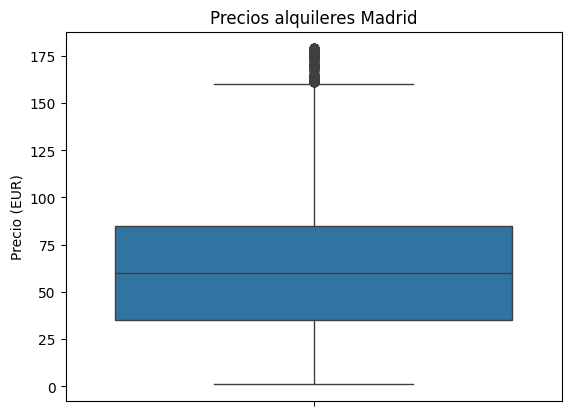

In [ ]:
sns.boxplot(
    data=df_total[df_total['price']< 180],
            y="price")
plt.title('Precios alquileres Madrid', fontsize=12)
plt.ylabel('Precio (EUR)', fontsize=10)



In [8]:
#Hipotesis 1: La ventaja "Superhost" 

#Cuantos proveedores son superhost y cual es el precio promedio por mes + reviews.
superhost_analysis = df_total.groupby('host_is_superhost').agg(price_mediana=('price', 'median'),reviews_por_mes=('reviews_per_month', 'mean')).reset_index()
superhost_analysis['host_is_superhost'] = superhost_analysis['host_is_superhost'].replace({0: 'No Superhost', 1: 'Superhost'})
print(superhost_analysis.set_index('host_is_superhost'))



                   price_mediana  reviews_por_mes
host_is_superhost                                
No Superhost                65.0         1.333928
Superhost                   69.0         2.647143


In [9]:
#El precio promedio por noche de un super host es de 4EUR mas alto que el de uno que no es superhost. 
#Y las reviews muestran un doble de ocupacio de un super host vs un no superhost, 
# es decir se reserva el doble de noches que un alquiler que no es superhost. Garantizado un flujo de ingresos mayor.

In [10]:
#Hipotesis 2: Valoracion de amenities. 
# Considero que el Wifi y Cocina son amenities que se valora mucho mas que por sobre la tv, aire etc.
# Por lo que quiero ver cuanto lo valoran los usuarios y la diferencia en el costo vs alquileres que no tienen.
avg_price = df_total['price'].mean()
df_low_price= df_total[df_total["price"]<avg_price]
amenities_analysis= df_low_price.groupby(["amenities_wifi_internet", "amenities_kitchen"])["review_scores_value"].mean().reset_index()
amenities_analysis.columns= ["Tiene WiFi", "Tiene Cocina", "Avg Review"]
print(amenities_analysis)


   Tiene WiFi  Tiene Cocina  Avg Review
0           0             0    4.827338
1           0             1    6.019097
2           1             0    7.485695
3           1             1    7.844129


In [11]:
#Nos muestra entonces que la puntiacion mas alta es la que tiene ambos amenities, tanto wifi como cocina. 
#Aun asi a los huespedes les importa mas el wifi que la cocina.

In [12]:
# Hipotesis 3: Precio por Distancia al Centro (Sol) vs Precio por capacidad?
precio_medio_barrio= df_total.groupby('neighbourhood')['price'].median().sort_values(ascending=False).reset_index()
print(precio_medio_barrio.head(10).to_string(index=False))

 neighbourhood  price
     Recoletos  120.0
       El Viso  120.0
El Tréntaiseis  105.0
    Castellana  100.0
Hispanoamérica   90.0
           Sol   90.0
       Almagro   89.5
     Salamanca   85.0
     Jerónimos   85.0
          Goya   85.0


In [13]:
#Exite entonces una correlacion entre el precio vs distancia al centro por tamaño?
import numpy as np
df_corr= df_total[df_total["price"]<500]
df_corr["Tamano"] = np.where(df_corr["bedrooms"] >= 3, "Grande", "Pequeña")


C:\Users\User\AppData\Local\Temp\ipykernel_35420\3966682159.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_corr["Tamano"] = np.where(df_corr["bedrooms"] >= 3, "Grande", "Pequeña")


In [14]:
#Distancias al centro por grupo:
def categ_dis(dist_km_sol):
    if dist_km_sol <= 1:
        return 'Central'
    elif dist_km_sol <= 3:
        return "Cercano"
    else:
        return "Periferico"

In [15]:
df_corr['Distancia_Grupo'] = df_total['dist_km_sol'].apply(categ_dis)

C:\Users\User\AppData\Local\Temp\ipykernel_35420\3219389075.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_corr['Distancia_Grupo'] = df_total['dist_km_sol'].apply(categ_dis)


In [16]:
median_data = df_corr.groupby(["Distancia_Grupo", "Tamano"])["price"].median().reset_index()
median_data.columns = ['Distancia_Grupo', 'Tamano', 'Precio_Mediano']

In [17]:
h3_analysis = df_corr.groupby(["dist_km_sol", "Tamano"])["price"].median().unstack(level="Tamano")
print(h3_analysis)

Tamano       Grande  Pequeña
dist_km_sol                 
0.000000       95.0     75.0
0.104131      420.0     80.0
0.192046      120.0     92.5
0.446113      157.5     95.0
0.525743      237.5     75.0
...             ...      ...
16.050518       NaN     50.0
16.283261       NaN     35.0
16.508490       NaN     19.0
18.968511       NaN     23.0
19.433900       NaN     33.0

[6630 rows x 2 columns]


Text(0, 0.5, 'Precio Mediano (EUR)')

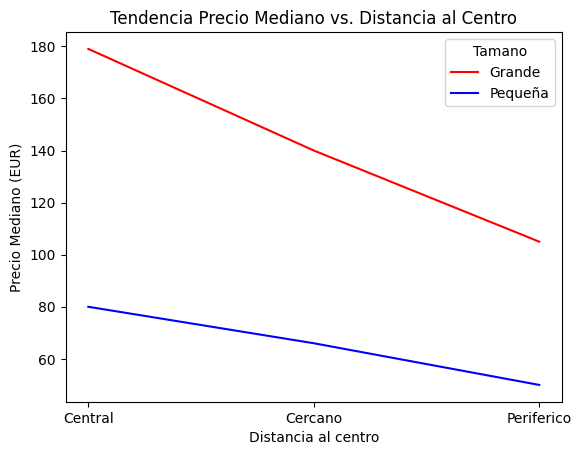

In [18]:
sns.lineplot(
    data=median_data,
    x="Distancia_Grupo",
    y="Precio_Mediano",
    hue="Tamano",
    palette={"Grande": "red", "Pequeña": "blue"}
)

plt.title('Tendencia Precio Mediano vs. Distancia al Centro', fontsize=12)
plt.xlabel('Distancia al centro', fontsize=10)
plt.ylabel('Precio Mediano (EUR)', fontsize=10)